>>> Wygenerowano cechy fizyczne. Nowy kształt danych: (563, 20)

>>> Start optymalizacji Walk-Forward (SVM RBF + Bloch Purity)...

--- WYNIKI WZBOGACONEGO SVM OOS ---
Accuracy: 0.5401 (Thresh = 0.50)
AUC ROC:  0.5248


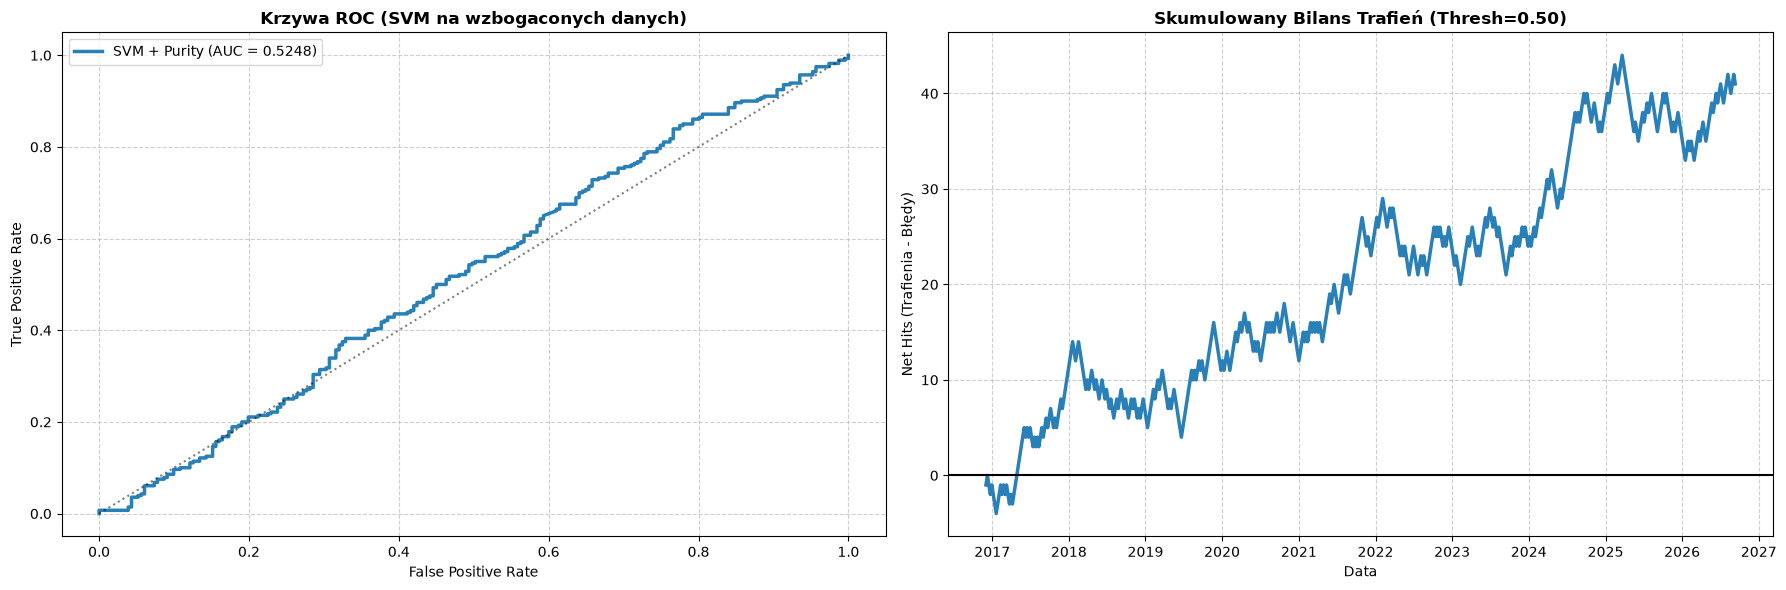

In [4]:
%matplotlib inline

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. KONFIGURACJA DANYCH
# ==========================================
PLIK_KACHE = "phi_odra_Top5_Rank1_Opt_q1_0.86_1.00_0.80_0.27_0.95.npz" 
csv_path = "dataset_final.csv" if os.path.exists("dataset_final.csv") else "dane/dataset_final.csv"

df = pd.read_csv(csv_path, index_col=0)
df.index = pd.to_datetime(df.index)
y_raw = df["target_y"].astype(int).values
dates_raw = df.index.values

LOOKBACK = 52
y = y_raw[LOOKBACK:]
dates = dates_raw[LOOKBACK:]

loaded_archive = np.load(PLIK_KACHE, allow_pickle=True)
first_key = loaded_archive.files[0]
Phi_raw = loaded_archive[first_key]

# ==========================================
# 2. FIZYCZNA INŻYNIERIA CECH (BLOCH VECTOR PURITY)
# ==========================================
num_samples = Phi_raw.shape[0]
num_qubits = 5
R_features = np.zeros((num_samples, num_qubits))

for i in range(num_samples):
    for q in range(num_qubits):
        # Pobranie rzutów X, Y, Z dla danego kubitu
        x_val = Phi_raw[i, 3*q + 0]
        y_val = Phi_raw[i, 3*q + 1]
        z_val = Phi_raw[i, 3*q + 2]
        
        # Obliczenie długości wektora (promienia na sferze Blocha)
        R_features[i, q] = np.sqrt(x_val**2 + y_val**2 + z_val**2)

# Doklejamy 5 nowych cech fizycznych do 15 rzutów z QPU (razem 20 cech)
Phi_enhanced = np.hstack((Phi_raw, R_features))

print(f">>> Wygenerowano cechy fizyczne. Nowy kształt danych: {Phi_enhanced.shape}")

# ==========================================
# 3. TRENOWANIE KROCZĄCE: SVM RBF NA WZBOGACONYCH DANYCH
# ==========================================
print("\n>>> Start optymalizacji Walk-Forward (SVM RBF + Bloch Purity)...")

TRAIN_WINDOW = 52
inner_cv = TimeSeriesSplit(n_splits=3)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True, random_state=42))
])

# Parametry strojone pod 20 wymiarów
param_grid = {
    "svm__C": [0.1, 1.0, 5.0, 10.0],
    "svm__gamma": ["scale", "auto", 0.01, 0.1] 
}

results = {"y_true": [], "dates": [], "prob": []}

for t in range(TRAIN_WINDOW, len(y)):
    X_tr, X_te = Phi_enhanced[t - TRAIN_WINDOW : t], Phi_enhanced[t : t + 1]
    y_tr = y[t - TRAIN_WINDOW : t]
    
    results["y_true"].append(y[t])
    results["dates"].append(dates[t])
    
    search = GridSearchCV(pipeline, param_grid, cv=inner_cv, scoring="roc_auc", n_jobs=-1)
    search.fit(X_tr, y_tr)
    
    results["prob"].append(search.predict_proba(X_te)[0, 1])

y_true = np.array(results["y_true"])
prob_preds = np.array(results["prob"])

# SZTYWNY PRÓG 0.50 
final_preds = (prob_preds > 0.5).astype(int)
acc = accuracy_score(y_true, final_preds)
auc = roc_auc_score(y_true, prob_preds)

# ==========================================
# 4. WYNIKI I WIZUALIZACJA
# ==========================================
print(f"\n--- WYNIKI WZBOGACONEGO SVM OOS ---")
print(f"Accuracy: {acc:.4f} (Thresh = 0.50)")
print(f"AUC ROC:  {auc:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

fpr, tpr, _ = roc_curve(y_true, prob_preds)
ax[0].plot(fpr, tpr, color='#2980b9', lw=2.5, label=f'SVM + Purity (AUC = {auc:.4f})')
ax[0].plot([0, 1], [0, 1], 'k:', alpha=0.5)
ax[0].set_title('Krzywa ROC (SVM na wzbogaconych danych)', fontweight='bold')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.6)

net_hits = np.cumsum(np.where(final_preds == y_true, 1, -1))
ax[1].plot(results["dates"], net_hits, color='#2980b9', lw=2.5)
ax[1].axhline(0, color='black', lw=1.5)
ax[1].set_title('Skumulowany Bilans Trafień (Thresh=0.50)', fontweight='bold')
ax[1].set_xlabel('Data')
ax[1].set_ylabel('Net Hits (Trafienia - Błędy)')
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()